## Setup

In [1]:
from typing import Any, Literal
from pathlib import Path
import json
from time import monotonic
from collections import defaultdict

import pandas as pd
from tqdm.auto import tqdm
from matplotlib import pyplot as plt

from pydantic import BaseModel, Field
from openai import OpenAI
from sglang import set_default_backend, RuntimeEndpoint

tqdm.pandas()  # load tqdm's pandas support
pd.set_option("display.max_colwidth", 400)

## Check if Humans agree among themselves

In [2]:
path = Path("eval-all/llm_judge_human_reference/human-csv")
all_people = (
    pd.concat(
        {
            "felix": pd.read_csv(path / "felix.csv", index_col=0),
            "matthias": pd.read_csv(path / "matthias.csv", index_col=0),
            "paul": pd.read_csv(path / "paul.csv", index_col=0),
        },
    )
    .reset_index()
    .rename(columns={"level_0": "person"})
    .drop(columns={"level_1"})
)
# all_people.head()

In [3]:
grouped = all_people.groupby(["sample_id", "question_id", "model", "setting", "mode"])
assert grouped.apply(lambda x: len(x) == 3).all()

agreement = grouped.apply(lambda x: x["human_judge"].nunique())
agreement.value_counts()

1    177
2     23
Name: count, dtype: int64

In [4]:
# 1 means all agree, 2 means two agree, 3 means all disagree
agreement.value_counts(normalize=True)[1]

0.885

In [5]:
# The average variance of the agreement per sample
avg_var = grouped.apply(lambda x: x["human_judge"].var()).mean()
print(f"Average variance of agreement: {avg_var:.4f}")

Average variance of agreement: 0.0433


In [6]:
# Explicitly show the ones where humans disagree
# for entries in grouped.filter(lambda x: x["human_judge"].nunique() > 1).groupby(
#     ["sample_id", "question_id", "model", "setting", "mode"]
# ):
#     print(entries[1])
#     print()

In [7]:
avg_score = grouped.aggregate({"human_judge": "mean"})
avg_score.to_csv(path / "avg_score.csv")

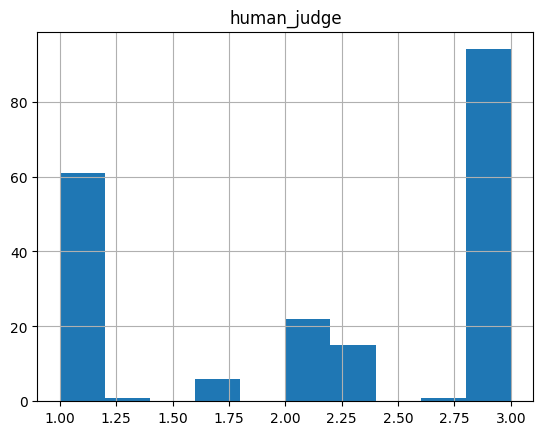

In [8]:
avg_score.hist()
pass

## Prepare the data

In [9]:
base = Path(".").resolve() / "eval-all" / "llm_judge_human_reference"
assert base.is_dir() and base.exists()
base


PosixPath('/workspaces/ts-qa/eval-all/llm_judge_human_reference')

In [10]:
# df = pd.read_hdf(base / "llmjudge_eval_set.h5", key="data")
eval_set = pd.read_csv(base / "llmjudge_eval_set.csv").drop(columns=["Unnamed: 0"])
eval_set = eval_set.join(avg_score, on=avg_score.index.names)
# eval_set


## Setup LLM backend

In [11]:
from pandarallel import pandarallel

pandarallel.initialize(nb_workers=64, progress_bar=True, verbose=1)

In [12]:
server_url = "http://docker-ts-qa-sg-run-5ba9c8d702c6:30000"

In [13]:
# repo_id = "meta-llama/Llama-3.2-3B-Instruct"
# print(
#     f'Run:\n\npython -m sglang.launch_server --model-path {repo_id} --port 30000 --host 0.0.0.0\n\n... and wait for "The server is fired up and ready to roll!" to appear.'
# )
set_default_backend(RuntimeEndpoint(server_url))  # Checks the connection

## The judge

In [14]:
# Duplicate the dataframe for averaging over multiple seeds
num_seeds = 10
eval_set = pd.concat([eval_set] * num_seeds, ignore_index=True)
eval_set.shape

(2000, 13)

In [ ]:
JUDGE_PROMPT_TEMPLATE = """You will be given a scene_description with timestamps and a scene_question regarding that scene. You will also be given a reference_answer and system_answer couple.
Your task is to provide a TotalRating scoring how well the system_answer answers the user concerns expressed in the scene_question. The reference_answer is provided as reference for a very good answer.
Give your answer on a scale of 1 to 3, where 1 means that the system_answer is not helpful at all, and 3 means that the system_answer completely and helpfully addresses the scene_question.
You will also provide a brief rationale for your rating.

Here is the scale you should use to build your answer:
1: The system_answer is terrible: the answer is factually incorrect or corrupt in some way (e.g., empty or nonsensical)
2: The system_answer is bad: somewhat correctly answers the scene_question like the reference_answer, yet contains additional useless/ambiguous/wrong information or is incomplete
3: The system_answer is good: correctly answers the scene_question and is helpful in the context of the scene

Provide your assessment in the following JSON format:
{{
    "BriefRationale": "<your rationale, at most 3 sentences>",
    "TotalRating": <your rating>
}}

You MUST provide values for "BriefRationale" and "TotalRating" in your answer.
Do NOT respond with any other text in your answer.
Immediately, start with the JSON object, without any additional text or explanation.
Make sure to output complete and valid JSON.

Now here are the question and answer:
- scene_description: {scene_description}
- scene_question: {scene_question}
- reference_answer: {reference_answer}
- system_answer: {system_answer}

Provide your assessment.
"""


max_rationale = 500


class JudgeResponse(BaseModel):
    BriefRationale: str = Field(
        ..., max_length=max_rationale, description="Your rationale, at most 3 sentences"
    )
    TotalRating: Literal[1, 2, 3] = Field(
        ...,
        description="Your rating on a scale of 1 to 3",
    )


client = OpenAI(
    api_key="EMPTY",
    base_url=server_url + "/v1",
)


def sglang_llm_judge(row):
    scene_description = row["textual_description"]
    prompt = JUDGE_PROMPT_TEMPLATE.format(
        scene_description=scene_description,
        scene_question=row["question"],
        reference_answer=row["answer_text"],
        system_answer=row["prediction_text"],
    )
    chat_response = client.chat.completions.create(
        model="IGNORED",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=8192,  # Leave enough room for thinking and response
        presence_penalty=1.5,
        # Non-thinking mode (Qwen3):
        # temperature=0.7,
        # top_p=0.8,
        # extra_body={
        #     "top_k": 20,
        #     "chat_template_kwargs": {"enable_thinking": False},
        # },
        # Thinking mode (Qwen3):
        temperature=0.6,
        top_p=0.95,
        extra_body={
            "top_k": 20,
            "chat_template_kwargs": {"enable_thinking": True},
        },
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "JudgeResponse",
                "schema": JudgeResponse.model_json_schema(),
            },
        },
    )
    return chat_response.choices[0].message.content


before = monotonic()

df = eval_set.copy()
df["llm_judge_raw"] = df.parallel_apply(
    lambda x: (
        x["llm_judge_raw"]
        if "llm_judge_raw" in x and x["llm_judge_raw"] != pd.NA
        else sglang_llm_judge(x)
    ),
    axis=1,
)

after = monotonic()
print(f"LLM judge took {after - before:.2f} seconds for {len(df)} rows.")
print(
    f"That is {len(df) / (after - before):.2f} rows per second or {(after - before) / len(df):.2f} seconds per row."
)


def decode(response) -> dict[str, Any]:
    try:
        return json.loads(response)
    except json.JSONDecodeError as e:
        print(f"Failed to decode response: {response}, error: {e}")
        return defaultdict(lambda: pd.NA)


df[["llm_judge_rationale", "llm_judge_score"]] = (
    df["llm_judge_raw"]
    .apply(decode)
    .apply(pd.Series)[["BriefRationale", "TotalRating"]]
)

LLM judge took 274.97 seconds for 2000 rows.
That is 7.27 rows per second or 0.14 seconds per row.


In [16]:
# Count number of NAs in the llm_judge_score column
na_count = df["llm_judge_score"].isna().sum()
print(
    f"Number of NAs in llm_judge_score: {na_count} out of {len(df)} rows ({na_count / len(df) * 100:.2f}%)"
)

Number of NAs in llm_judge_score: 0 out of 2000 rows (0.00%)


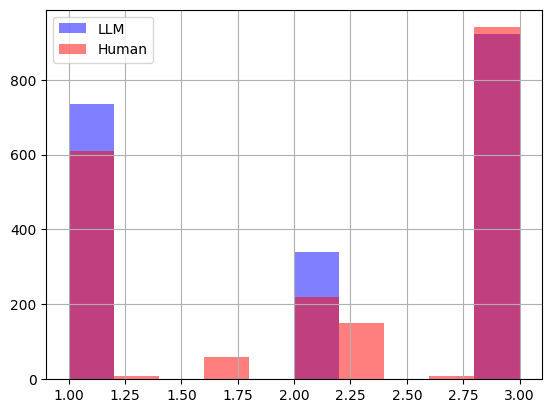

In [17]:
df_not_na = df.dropna(subset=["llm_judge_score"]).astype({"llm_judge_score": float})

# Plot both histrograms in one plot
df_not_na["llm_judge_score"].hist(alpha=0.5, color="blue", label="LLM")
df_not_na["human_judge"].hist(alpha=0.5, color="red", label="Human")
plt.legend()
pass

In [18]:
print("Correlation between LLM-as-a-judge and the human raters:")
print(
    f"Mean difference: {(df_not_na['llm_judge_score'] - df_not_na['human_judge']).abs().mean():.3f}"
)
print(f"Pearson: {df['llm_judge_score'].corr(df['human_judge'], method='pearson'):.3f}")
print(
    f"Spearman: {df['llm_judge_score'].corr(df['human_judge'], method='spearman'):.3f}"
)
print(f"Kendall: {df['llm_judge_score'].corr(df['human_judge'], method='kendall'):.3f}")


Correlation between LLM-as-a-judge and the human raters:
Mean difference: 0.149
Pearson: 0.912
Spearman: 0.927
Kendall: 0.878
